In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.patheffects as path_effects
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames
import sunpy.map
from sunpy.net import Fido
from sunpy.net import attrs as a
import pandas as pd
import os
import sys
from datetime import datetime, timedelta
from PIL import Image
from scipy import stats

from PF2nlfff.packages import *
from PF2nlfff.model_3D import *
from PF2nlfff.tools import *
from PF2nlfff.nlfff_module import *

In [ ]:
def move_to_device(module, device):
    for name, child in module.named_children():
        # 递归处理子模块
        move_to_device(child, device)
        # print(name, child.device)
    # 迁移当前模块的参数和缓冲区
    module=module.to(device)
    return module
    
device = 'cuda:1'
netG = torch.load('GAN_models/netG.pkl')#.to(torch.device(device))
netG.encoder_device=torch.device(device)
netG.decoder_device=torch.device(device)
netG = move_to_device(netG, device)
model = PICNN(PF_data, net=netG, device=torch.device(device))

model.L_ff  = 1.e1
model.L_div = 1.e1
model.L_bc  = 1.e9
model.L_Sj  = 1.e1
model.L_fi  = 1.e3
model.L_lf  = 1.e0
model.print_epoch=10
model.save_epoch=5000
model._use_mf = True
model.iter = 0
model.loss_list = []
model.L_list = []
model.fi_list = []
model.sJ_list = []
LR = 1.e-4
step_size = 1
gamma=0.9995
model.train(
    10001, 
    lr=LR, 
    Delta=step_size, 
    gamma=gamma, 
    save_best=True, 
    save_first=False,
    save_models_dir='./trainer/test_model_v8', 
    save_model_name='retrained_test'
           )

In [76]:
def move_to_device(module, device):
    for name, child in module.named_children():
        # 递归处理子模块
        move_to_device(child, device)
        # print(name, child.device)
    # 迁移当前模块的参数和缓冲区
    module=module.to(device)
    return module
    
device = 'cuda:1'
netG = torch.load('GAN_models/netG.pkl')#.to(torch.device(device))
netG.encoder_device=torch.device(device)
netG.decoder_device=torch.device(device)
netG = move_to_device(netG, device)
model = PICNN(PF_data, net=netG, device=torch.device(device))
gan_model = torch.load('GAN_models/best_model.pkl', weights_only=False)

model.L_ff  = 1.e1
model.L_div = 1.e1
model.L_bc  = 1.e9
model.L_Sj  = 1.e1
model.L_fi  = 1.e3
model.L_lf  = 1.e0
model.print_epoch=10
model.save_epoch=5000
model._use_mf = True
model.iter = 0
model.loss_list = []
model.L_list = []
model.fi_list = []
model.sJ_list = []
LR = gan_model.scheduler.get_last_lr()[-1]
step_size = 1
gamma=0.9995
model.train(
    10001, 
    lr=LR, 
    Delta=step_size, 
    gamma=gamma, 
    save_best=True, 
    save_first=False,
    save_models_dir='./trainer/test_model_v8', 
    save_model_name='retrained_test'
           )

Iter 00000, Loss: 6.368e+08, Loss_div: 2.409e+08,Loss_ff: 3.817e+08, Loss_bc: 6.996e+06, Loss_lf: 7.189e+06, wall_time: 2.025e+00 sec, lr: 4.136e-05
create the DIR. : ./trainer/test_model_v8
Iter 00010, Loss: 6.427e+08, Loss_div: 2.406e+08,Loss_ff: 3.877e+08, Loss_bc: 7.098e+06, Loss_lf: 7.359e+06, wall_time: 3.201e+01 sec, lr: 4.115e-05
Iter 00020, Loss: 6.362e+08, Loss_div: 2.418e+08,Loss_ff: 3.803e+08, Loss_bc: 6.998e+06, Loss_lf: 7.102e+06, wall_time: 6.921e+01 sec, lr: 4.094e-05
Iter 00030, Loss: 6.345e+08, Loss_div: 2.427e+08,Loss_ff: 3.777e+08, Loss_bc: 7.036e+06, Loss_lf: 7.045e+06, wall_time: 1.803e+02 sec, lr: 4.074e-05
Iter 00040, Loss: 6.382e+08, Loss_div: 2.432e+08,Loss_ff: 3.806e+08, Loss_bc: 7.266e+06, Loss_lf: 7.128e+06, wall_time: 2.178e+02 sec, lr: 4.054e-05
Iter 00050, Loss: 6.380e+08, Loss_div: 2.422e+08,Loss_ff: 3.814e+08, Loss_bc: 7.250e+06, Loss_lf: 7.124e+06, wall_time: 2.464e+02 sec, lr: 4.034e-05
Iter 00060, Loss: 6.364e+08, Loss_div: 2.424e+08,Loss_ff: 3.795e

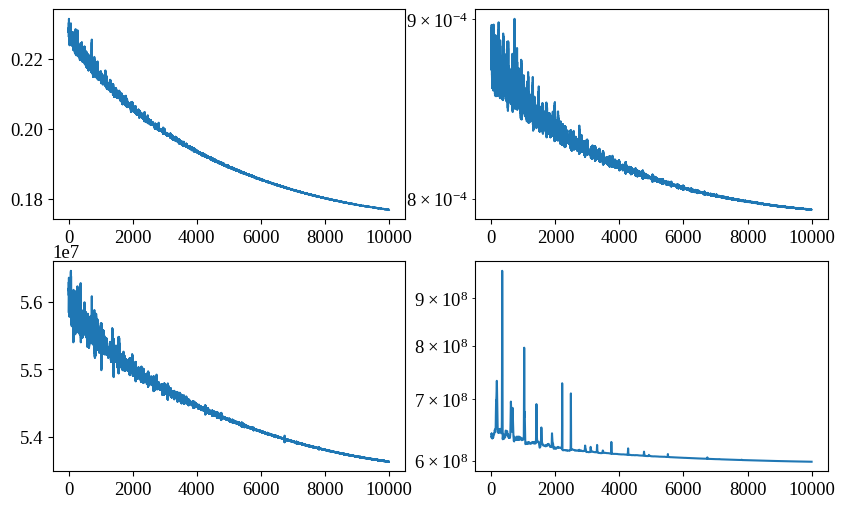

In [77]:
plt.figure(figsize=(10,6))
plt.subplot(221)
plt.plot(model.sJ_list)

plt.subplot(222)
plt.plot(model.fi_list)
plt.yscale('log')

plt.subplot(223)
plt.plot(model.L_list)

plt.subplot(224)
plt.plot(model.loss_list)
plt.yscale('log')

plt.show()